# LSTM Stock Price Prediction

In this notebook, I will:

- Load the prepared AAPL sequence data
- Build an LSTM model with PyTorch
- Understand hidden state and cell state
- Train the model using mini-batches
- Monitor training and validation loss
- Save the best model
- Evaluate the model on unseen test data
- Compare the LSTM against the naive baseline

## Preface: 
Since this experiment did not achieve the desired results, a different experiment will be conducted in the next notebook.

In [1]:
from pathlib import Path
import copy
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
def get_device() -> torch.device:
    if torch.backends.mps.is_available():
        return torch.device("mps")

    if torch.cuda.is_available():
        return torch.device("cuda")

    return torch.device("cpu")


device = get_device()

torch.manual_seed(42)
np.random.seed(42)

print("Device:", device)

Device: mps


In [3]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_directory = project_root / "data"
models_directory = project_root / "models"
results_directory = project_root / "results"

models_directory.mkdir(exist_ok=True)
results_directory.mkdir(exist_ok=True)

In [4]:
prepared_data_path = (
    data_directory / "aapl_prepared.npz"
)

prepared_data = np.load(
    prepared_data_path
)

X_train = prepared_data["X_train"]
y_train = prepared_data["y_train"]

X_validation = prepared_data["X_validation"]
y_validation = prepared_data["y_validation"]

X_test = prepared_data["X_test"]
y_test = prepared_data["y_test"]

In [5]:
print("Train:", X_train.shape, y_train.shape)
print(
    "Validation:",
    X_validation.shape,
    y_validation.shape,
)
print("Test:", X_test.shape, y_test.shape)

Train: (1916, 20, 1) (1916, 1)
Validation: (415, 20, 1) (415, 1)
Test: (415, 20, 1) (415, 1)


In [6]:
scaler_path = (
    data_directory / "aapl_scaler.joblib"
)

scaler = joblib.load(
    scaler_path
)

In [7]:
X_train_tensor = torch.from_numpy(
    X_train
)

y_train_tensor = torch.from_numpy(
    y_train
)

X_validation_tensor = torch.from_numpy(
    X_validation
)

y_validation_tensor = torch.from_numpy(
    y_validation
)

X_test_tensor = torch.from_numpy(
    X_test
)

y_test_tensor = torch.from_numpy(
    y_test
)

In [8]:
print(X_train_tensor.dtype)
print(X_train_tensor.shape)

torch.float32
torch.Size([1916, 20, 1])


In [9]:
BATCH_SIZE = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

validation_dataset = TensorDataset(
    X_validation_tensor,
    y_validation_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [10]:
class LSTMModel(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        num_layers: int,
        dropout: float,
    ) -> None:
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1,
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:

        lstm_output, _ = self.lstm(x)

        last_time_step = lstm_output[:, -1, :]

        prediction = self.output_layer(
            last_time_step
        )

        return prediction

In [11]:
INPUT_SIZE = 1
HIDDEN_SIZE = 32
NUM_LAYERS = 2
DROPOUT = 0.2

LEARNING_RATE = 0.001
NUMBER_OF_EPOCHS = 100
PATIENCE = 15

In [12]:
model = LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
)

model = model.to(device)

print(model)

LSTMModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


In [13]:
batch_X, batch_y = next(
    iter(train_loader)
)

batch_X = batch_X.to(device)

with torch.no_grad():
    sample_predictions = model(
        batch_X
    )

print("Input shape:", batch_X.shape)
print(
    "Prediction shape:",
    sample_predictions.shape,
)

Input shape: torch.Size([32, 20, 1])
Prediction shape: torch.Size([32, 1])


In [14]:
loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [15]:
training_losses = []
validation_losses = []

best_validation_loss = float("inf")
best_model_state = None

epochs_without_improvement = 0

In [18]:
training_start_time = time.perf_counter()

In [19]:
for epoch in range(NUMBER_OF_EPOCHS):
    model.train()

    total_training_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        predictions = model(batch_X)

        loss = loss_function(
            predictions,
            batch_y,
        )

        loss.backward()

        optimizer.step()

        total_training_loss += (
            loss.item()
            * batch_X.size(0)
        )

    average_training_loss = (
        total_training_loss
        / len(train_dataset)
    )

    training_losses.append(
        average_training_loss
    )

    model.eval()

    total_validation_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in validation_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_X)

            validation_loss = loss_function(
                predictions,
                batch_y,
            )

            total_validation_loss += (
                validation_loss.item()
                * batch_X.size(0)
            )

    average_validation_loss = (
        total_validation_loss
        / len(validation_dataset)
    )

    validation_losses.append(
        average_validation_loss
    )

    if average_validation_loss < best_validation_loss:
        best_validation_loss = (
            average_validation_loss
        )

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train: {average_training_loss:.6f} | "
            f"Validation: {average_validation_loss:.6f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping at epoch "
            f"{epoch + 1}"
        )
        break

Early stopping at epoch 1


In [20]:
training_end_time = time.perf_counter()

training_time = (
    training_end_time
    - training_start_time
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

Training time: 7.09 seconds


In [21]:
model.load_state_dict(
    best_model_state
)

<All keys matched successfully>

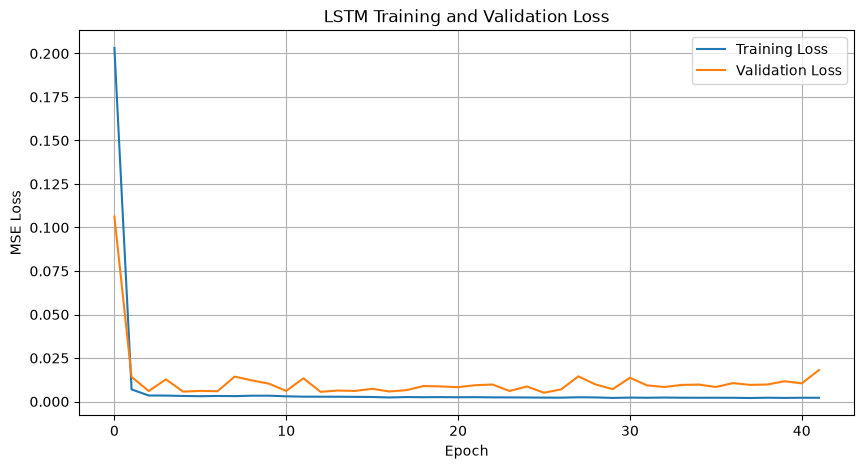

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    training_losses,
    label="Training Loss",
)

plt.plot(
    validation_losses,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
model.eval()

with torch.no_grad():
    test_predictions_scaled = model(
        X_test_tensor.to(device)
    )

test_predictions_scaled = (
    test_predictions_scaled
    .cpu()
    .numpy()
)

In [24]:
lstm_predictions = (
    scaler.inverse_transform(
        test_predictions_scaled
    )
    .ravel()
)

actual_test_prices = (
    scaler.inverse_transform(
        y_test
    )
    .ravel()
)

In [25]:
lstm_mae = mean_absolute_error(
    actual_test_prices,
    lstm_predictions,
)

lstm_mse = mean_squared_error(
    actual_test_prices,
    lstm_predictions,
)

lstm_rmse = np.sqrt(
    lstm_mse
)

print(f"LSTM MAE : {lstm_mae:.4f}")
print(f"LSTM MSE : {lstm_mse:.4f}")
print(f"LSTM RMSE: {lstm_rmse:.4f}")

LSTM MAE : 36.3403
LSTM MSE : 1713.5226
LSTM RMSE: 41.3947


In [26]:
baseline_scaled = X_test[
    :,
    -1,
    0,
].reshape(-1, 1)

baseline_predictions = (
    scaler.inverse_transform(
        baseline_scaled
    )
    .ravel()
)

In [27]:
baseline_mae = mean_absolute_error(
    actual_test_prices,
    baseline_predictions,
)

baseline_mse = mean_squared_error(
    actual_test_prices,
    baseline_predictions,
)

baseline_rmse = np.sqrt(
    baseline_mse
)

In [28]:
comparison_df = pd.DataFrame({
    "model": [
        "Naive Baseline",
        "LSTM",
    ],
    "mae": [
        baseline_mae,
        lstm_mae,
    ],
    "mse": [
        baseline_mse,
        lstm_mse,
    ],
    "rmse": [
        baseline_rmse,
        lstm_rmse,
    ],
})

comparison_df.round(4)

,model,mae,mse,rmse
0,Naive Baseline,2.5887,14.7321,3.8382
1,LSTM,36.3403,1713.5226,41.3947


In [29]:
clean_data_path = (
    data_directory / "aapl_clean.csv"
)

price_df = pd.read_csv(
    clean_data_path,
    parse_dates=["date"],
)

In [30]:
test_dates = (
    price_df["date"]
    .iloc[-len(actual_test_prices):]
    .to_numpy()
)

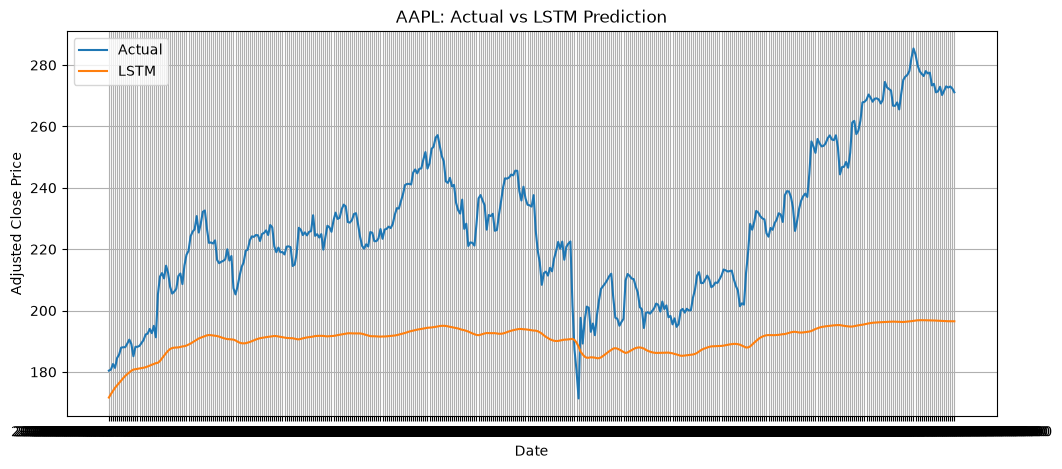

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_dates,
    actual_test_prices,
    label="Actual",
)

plt.plot(
    test_dates,
    lstm_predictions,
    label="LSTM",
)

plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.title("AAPL: Actual vs LSTM Prediction")
plt.legend()
plt.grid(True)
plt.show()

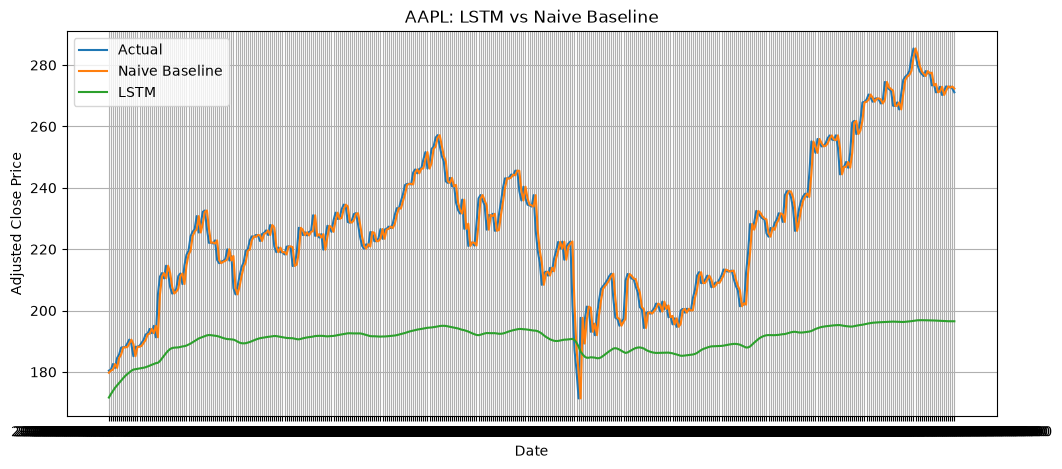

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_dates,
    actual_test_prices,
    label="Actual",
)

plt.plot(
    test_dates,
    baseline_predictions,
    label="Naive Baseline",
)

plt.plot(
    test_dates,
    lstm_predictions,
    label="LSTM",
)

plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")

plt.title(
    "AAPL: LSTM vs Naive Baseline"
)

plt.legend()
plt.grid(True)
plt.show()

In [33]:
results_df = pd.DataFrame({
    "date": test_dates,
    "actual": actual_test_prices,
    "baseline": baseline_predictions,
    "lstm": lstm_predictions,
})

results_df["lstm_error"] = (
    results_df["actual"]
    - results_df["lstm"]
)

results_df["lstm_absolute_error"] = (
    results_df["lstm_error"].abs()
)

results_df.head()

,date,actual,baseline,lstm,lstm_error,lstm_absolute_error
0,2024-05-07 00:00:00-04:00,180.432968,179.750443,171.655716,8.777252,8.777252
1,2024-05-08 00:00:00-04:00,180.769318,180.432968,172.803009,7.966309,7.966309
2,2024-05-09 00:00:00-04:00,182.579605,180.769318,173.845230,8.734375,8.734375
3,2024-05-10 00:00:00-04:00,181.321564,182.579605,174.832260,6.489304,6.489304
4,2024-05-13 00:00:00-04:00,184.521072,181.321564,175.627563,8.893509,8.893509


In [34]:
model_path = (
    models_directory
    / "aapl_lstm_model.pth"
)

torch.save(
    model.state_dict(),
    model_path,
)

print(
    "LSTM model saved to:",
    model_path,
)

LSTM model saved to: /Users/omurravli/Desktop/pythorch_stock_predict/models/aapl_lstm_model.pth


In [35]:
metrics_path = (
    results_directory
    / "lstm_metrics.csv"
)

lstm_metrics_df = pd.DataFrame({
    "model": ["LSTM"],
    "mae": [lstm_mae],
    "mse": [lstm_mse],
    "rmse": [lstm_rmse],
    "training_time_seconds": [
        training_time
    ],
})

lstm_metrics_df.to_csv(
    metrics_path,
    index=False,
)

lstm_metrics_df

,model,mae,mse,rmse,training_time_seconds
0,LSTM,36.340309,1713.522583,41.394717,7.087083


In [36]:
price_df = pd.read_csv(
    data_directory / "aapl_clean.csv",
    parse_dates=["date"],
)

train_end = int(len(price_df) * 0.70)
validation_end = int(len(price_df) * 0.85)

print(
    "Train price range:",
    price_df["price"].iloc[:train_end].min(),
    "→",
    price_df["price"].iloc[:train_end].max(),
)

print(
    "Validation price range:",
    price_df["price"].iloc[train_end:validation_end].min(),
    "→",
    price_df["price"].iloc[train_end:validation_end].max(),
)

print(
    "Test price range:",
    price_df["price"].iloc[validation_end:].min(),
    "→",
    price_df["price"].iloc[validation_end:].max(),
)

print(
    "LSTM prediction range:",
    lstm_predictions.min(),
    "→",
    lstm_predictions.max(),
)

Train price range: 20.54815101623535 → 177.78636169433594
Validation price range: 122.82760620117188 → 195.72378540039065
Test price range: 171.36598205566406 → 285.4131164550781
LSTM prediction range: 171.65572 → 196.87259


In [37]:
def predict_prices(model, X, scaler, device):
    model.eval()

    X_tensor = torch.from_numpy(X).to(device)

    with torch.no_grad():
        predictions_scaled = model(X_tensor)

    predictions_scaled = (
        predictions_scaled
        .cpu()
        .numpy()
    )

    predictions = (
        scaler.inverse_transform(predictions_scaled)
        .ravel()
    )

    return predictions

In [38]:
train_predictions = predict_prices(
    model,
    X_train,
    scaler,
    device,
)

validation_predictions = predict_prices(
    model,
    X_validation,
    scaler,
    device,
)

In [39]:
actual_train_prices = (
    scaler.inverse_transform(y_train)
    .ravel()
)

actual_validation_prices = (
    scaler.inverse_transform(y_validation)
    .ravel()
)

In [40]:
train_rmse = np.sqrt(
    mean_squared_error(
        actual_train_prices,
        train_predictions,
    )
)

validation_rmse = np.sqrt(
    mean_squared_error(
        actual_validation_prices,
        validation_predictions,
    )
)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {validation_rmse:.4f}")
print(f"Test RMSE: {lstm_rmse:.4f}")

print(
    "Train prediction range:",
    train_predictions.min(),
    "→",
    train_predictions.max(),
)

print(
    "Validation prediction range:",
    validation_predictions.min(),
    "→",
    validation_predictions.max(),
)

Train RMSE: 3.0531
Validation RMSE: 5.5945
Test RMSE: 41.3947
Train prediction range: 23.240074 → 173.721
Validation prediction range: 126.49934 → 183.64252


## Conclusion

In this experiment, an LSTM model was trained to predict the next adjusted closing price of AAPL using the previous 20 trading days.

The model performed reasonably well on the training and validation periods:

* **Training RMSE:** 3.0531
* **Validation RMSE:** 5.5945
* **Test RMSE:** 41.3947

However, its performance deteriorated significantly on the test period. The training data contained prices ranging approximately from **$20.55 to $177.79**, while the test period reached prices as high as **$285.41**. The LSTM predictions remained mostly within the range of approximately **$171.66 to $196.87**, showing that the model struggled to generalize to price levels substantially higher than those observed during training.

The naive persistence baseline, which simply predicts that the next day's price will be equal to the most recent known price, strongly outperformed the LSTM:

* **Naive Baseline RMSE:** 3.8382
* **LSTM RMSE:** 41.3947

This result demonstrates that a low training or validation error does not necessarily imply good generalization to future market conditions. Directly predicting absolute stock-price levels also makes the model sensitive to long-term changes in the price scale and market regime.

Therefore, this experiment will be retained as the **first baseline deep-learning approach rather than discarded**.

### Next Experiment

In the next experiment, the prediction target will be changed from the absolute stock price to **daily log returns**.

Instead of learning:

`previous 20 prices → next price`

the model will learn:

`previous 20 returns → next return`

The predicted return will then be converted back into a next-day price using the most recent known price.

This approach should reduce the model's dependence on absolute price levels and provide a more suitable representation for a non-stationary financial time series. The new model will again be compared against the naive baseline to determine whether it provides any genuine predictive improvement.
